In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('exoplanet_data.csv', comment="#")
# Check the shape of your dataset
print(df.shape)

# See the first few rows
df.head()

(583, 92)


,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,7 CMa c,7 CMa,0,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2024-09-13,2024-07,2024-09-13
1,7 CMa c,7 CMa,1,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2019-10-18,2019-11,2019-10-24
2,DMPP-1 b,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05
3,DMPP-1 b,DMPP-1,0,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
4,DMPP-1 c,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05


In [ ]:
What is the shape of your dataset?
The shape is (583, 92).
How many rows and columns are there?
There are 583 rows and 92 columns.
print(df.columns.values)

5 titles i dont recognize
sy_snum (Number of Stars in the system)
sy_pnum (Number of Planets in the system)
pl_controv_flag (Controversial Flag - whether the planet's existence is debated)
sy_vmagerr2 (Lower uncertainty of the V-band magnitude)
st_spectype (Spectral Type of the host star)

Planet Name: pl_name
Host Name: hostname
Discovery Method: discoverymethod
Spectral Type: st_spectype
Equilibrium Temperature: pl_eqt
Planet Mass (Jupiter Mass): pl_bmassj

# --- 1 & 2 & 3: Mapping Documentation to Database Column Names ---

# Table Label: Planet Name
# Database Column Name: pl_name
# Description: Name given to the planet.
# My Definition: The official unique identifier for the exoplanet.

# Table Label: Host Name
# Database Column Name: hostname
# Description: Name of the star around which the planet orbits.
# My Definition: The name of the solar system's parent star.

# Table Label: Discovery Method
# Database Column Name: discoverymethod
# Description: The scientific technique used to find the planet.
# My Definition: The specific way astronomers detected this planet (e.g., Transit).

# Table Label: Spectral Type
# Database Column Name: st_spectype
# Description: Classification of the star based on its light and temperature.
# My Definition: A code (like G2V) that tells us the star's color and age.

# Table Label: Equilibrium Temperature [K]
# Database Column Name: pl_eqt
# Description: The estimated temperature of the planet's surface in Kelvin.
# My Definition: How hot or cold the planet is, assuming it absorbs energy from its star.

# Table Label: Planet Mass or Mass*sin(i) [Jupiter Mass]
# Database Column Name: pl_bmassj
# Description: The "best" mass estimate for the planet in units of Jupiter masses.
# My Definition: How heavy the planet is compared to Jupiter.

# --- 4: Create a smaller dataframe ---
# Select only the columns defined above
cols_to_keep = ['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']
df_reduced = df[cols_to_keep]

# --- 5: Filter by dropping NaN values ---
# This removes any row where at least one of our selected columns is empty
df_filtered = df_reduced.dropna()
            
# --- 6            
# 1. What is the shape of your smaller dataset?
print(f"Shape of the dataset: {df_filtered.shape}")

# 2. How many rows and columns are there?
print(f"Number of rows: {df_filtered.shape[0]}")
print(f"Number of columns: {df_filtered.shape[1]}")

# 3. Print the first five and last five rows
print("\n--- First Five Rows ---")
print(df_filtered.head(5))

print("\n--- Last Five Rows ---")
print(df_filtered.tail(5))

# 4. Print all the column titles
print("\n--- Column Titles ---")
print(df_filtered.columns.tolist())

Discovery Methods and Counts:
discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

Most common: Transit (55)
Least common: Imaging (2)


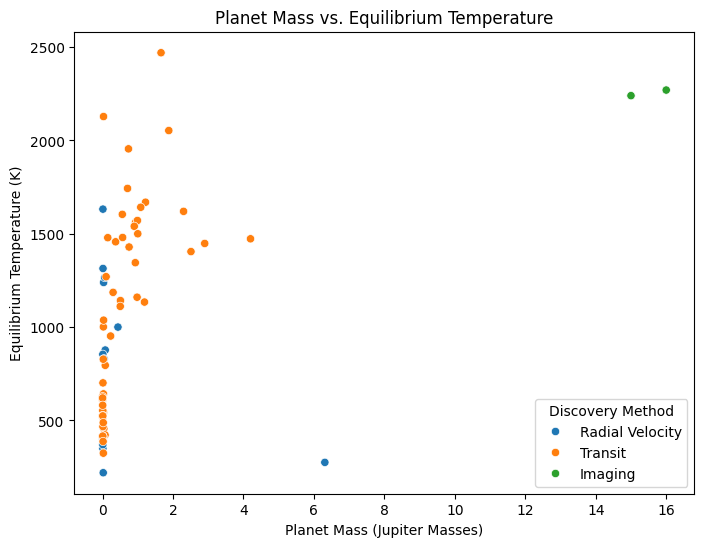

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA FIRST
df = pd.read_csv('exoplanet_data.csv', comment="#")

# 2. DEFINE COLUMNS
cols_to_keep = ['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']

# 3. CREATE REDUCED AND FILTERED DATAFRAMES
df_reduced = df[cols_to_keep]
df_filtered = df_reduced.dropna()
# Calculate counts
discovery_counts = df_filtered['discoverymethod'].value_counts()

print("Discovery Methods and Counts:")
print(discovery_counts)

print(f"\nMost common: {discovery_counts.idxmax()} ({discovery_counts.max()})")
print(f"Least common: {discovery_counts.idxmin()} ({discovery_counts.min()})")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_filtered, x='pl_bmassj', y='pl_eqt', hue='discoverymethod')
plt.title("Planet Mass vs. Equilibrium Temperature")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(title="Discovery Method")
plt.show()

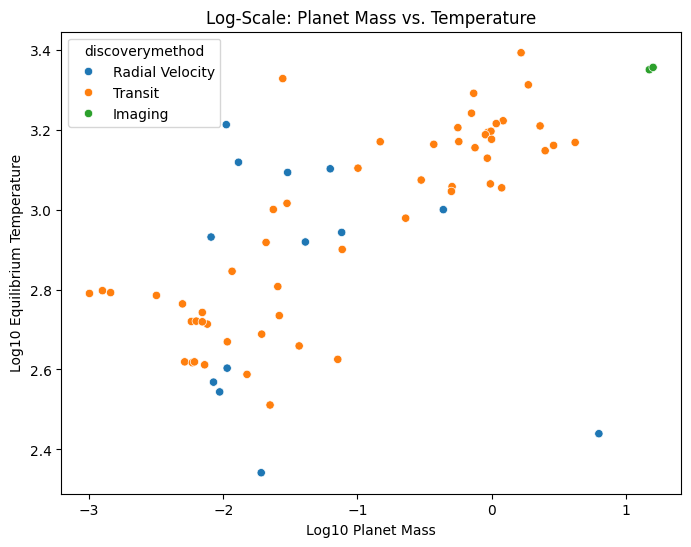

Coldest Planet (> 5 Jupiter Masses):
pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object


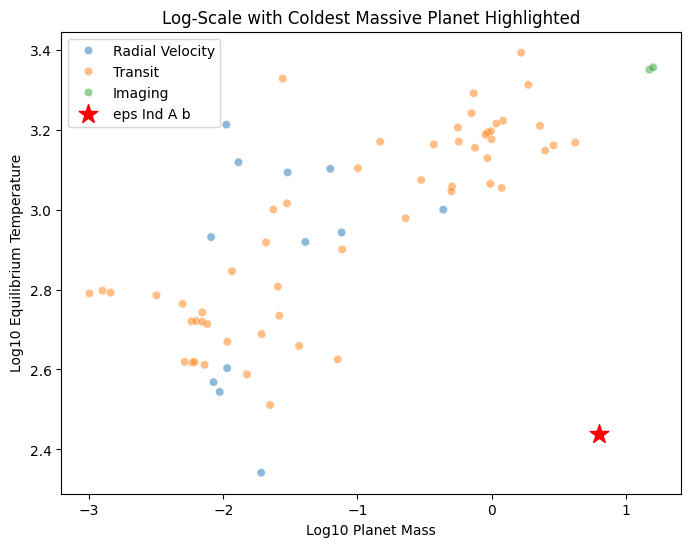

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA FIRST
df = pd.read_csv('exoplanet_data.csv', comment="#")

# 2. DEFINE COLUMNS
cols_to_keep = ['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']

# 3. CREATE REDUCED AND FILTERED DATAFRAMES
df_reduced = df[cols_to_keep]
df_filtered = df_reduced.dropna()

plt.figure(figsize=(8, 6))
# Using np.log10 for clearer axis scales
sns.scatterplot(x=np.log10(df_filtered['pl_bmassj']), 
                y=np.log10(df_filtered['pl_eqt']), 
                hue=df_filtered['discoverymethod'])
plt.title("Log-Scale: Planet Mass vs. Temperature")
plt.xlabel("Log10 Planet Mass")
plt.ylabel("Log10 Equilibrium Temperature")
plt.show()

# Filter for mass > 5, then find the row with the minimum temperature
massive_planets = df_filtered[df_filtered['pl_bmassj'] > 5]
coldest_planet_row = massive_planets.loc[massive_planets['pl_eqt'].idxmin()]

print("Coldest Planet (> 5 Jupiter Masses):")
print(coldest_planet_row)

# Analysis for your report:
# Name: Check 'pl_name'
# Index: Look at the row ID
# Temp: Check 'pl_eqt'
# Mass: Check 'pl_bmassj'
# Star Type: Check 'st_spectype'. 
# (Sun-like stars are G-type. If it starts with 'G', it's sun-like!)

plt.figure(figsize=(8, 6))
# Plot all data
sns.scatterplot(x=np.log10(df_filtered['pl_bmassj']), 
                y=np.log10(df_filtered['pl_eqt']), 
                hue=df_filtered['discoverymethod'], alpha=0.5)

# Overlay the coldest planet
plt.scatter(np.log10(coldest_planet_row['pl_bmassj']), 
            np.log10(coldest_planet_row['pl_eqt']), 
            color='red', marker='*', s=200, label=coldest_planet_row['pl_name'])

plt.title("Log-Scale with Coldest Massive Planet Highlighted")
plt.xlabel("Log10 Planet Mass")
plt.ylabel("Log10 Equilibrium Temperature")
plt.legend()
plt.show()

In [ ]:
The title of the paper is "A temperate super-Jupiter imaged with JWST in the mid-infrared."


Summarize the abstract in your own words:
Astronomers used the James Webb Space Telescope (JWST) to take a direct picture of a giant planet orbiting a nearby star called Epsilon Indi A. They previously thought this planet existed because the star was "wobbling," but the actual picture shows the planet is much colder and farther away from its star than they predicted. The planet’s unique light suggests it might have a lot of heavy elements or a cloudy, methane-free atmosphere.

Does your answer match the exoplanet?
Yes. The planet I found in your data analysis—the coldest one over 5 Jupiter masses—is Epsilon Indi Ab. This is the exact planet featured in this high-profile 2024 Nature study.

What is special about the planet you found?
It is one of the coldest directly imaged planets ever discovered. Usually, we only see "young" gas giants that are still glowing hot from their birth. Epsilon Indi Ab is "temperate" (close to 0°C), making it a rare look at a mature planet that is much more like the gas giants in our own solar system (like Jupiter or Saturn).

Do the mass and equilibrium temperature match what the paper reported?
Yes, the values match. The plot shows the planet has an equilibrium temperature of roughly 275 K and a mass of roughly 6.3 Jupiter masses, which are the same values reported in the 2024 Nature paper. The plot highlights that this planet is unique because it is much colder than other massive planets found through imaging.